# Forcaster Engine 

In [3]:
import sys
import os
import pandas as pd
import importlib

# 1. Setup paths and reload modules
sys.path.append(os.path.abspath('../src'))
import data_loader, modeller, forecaster
importlib.reload(data_loader)
importlib.reload(modeller)
importlib.reload(forecaster)

from data_loader import load_unified_data
from modeller import ImpactModeller
from forecaster import InclusionForecaster

# 2. Load the data (Make sure this path is correct)
df_main, df_impact = load_unified_data('../data/processed/ethiopia_fi_enriched.xlsx')

# 3. INITIALIZE THE ENGINES (This creates 'forecaster_engine')
impact_engine = modeller.ImpactModeller(df_main, df_impact)
forecaster_engine = forecaster.InclusionForecaster(df_main, impact_engine)

print("✅ SUCCESS: 'forecaster_engine' is now defined and ready.")

✅ SUCCESS: 'forecaster_engine' is now defined and ready.


# Setup and Data Ingestion 

In [4]:
import sys
import os
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../src'))
import data_loader, modeller, forecaster
importlib.reload(data_loader)
importlib.reload(modeller)
importlib.reload(forecaster)

from data_loader import load_unified_data
from modeller import ImpactModeller
from forecaster import InclusionForecaster

# Load data
df_main, df_impact = load_unified_data('../data/raw/ethiopia_fi_unified_data.xlsx')

# Initialize Task 3 Engine and Task 4 Forecaster
impact_engine = ImpactModeller(df_main, df_impact)
forecaster_engine = InclusionForecaster(df_main, impact_engine)

print("✅ Forecasting Engine Initialized Successfully!")

✅ Forecasting Engine Initialized Successfully!


# Generate Acess and Usage Forcast Tables 

In [5]:
# Forecast Access (Account Ownership)
df_access_fc = forecaster_engine.forecast_indicator('ACC_OWNERSHIP', [2025, 2026, 2027])

# Forecast Usage (Digital Payment Adoption / P2P Value proxy)
df_usage_fc = forecaster_engine.forecast_indicator('USG_P2P_COUNT', [2025, 2026, 2027])

print("--- 📊 Account Ownership Forecast (Access: 2025-2027) ---")
display(df_access_fc)

print("\n--- 💳 Digital Payment Usage Forecast (Usage: 2025-2027) ---")
display(df_usage_fc)

--- 📊 Account Ownership Forecast (Access: 2025-2027) ---


,year,indicator_code,baseline_trend,event_shock_pp,base_forecast,optimistic_scenario,pessimistic_scenario,ci_lower_95,ci_upper_95
0,2025,ACC_OWNERSHIP,55.68,5.0,60.68,73.90,46.97,48.47,72.90
1,2026,ACC_OWNERSHIP,58.50,7.0,65.50,79.12,51.18,53.28,77.72
2,2027,ACC_OWNERSHIP,61.32,7.0,68.32,81.93,54.00,56.10,80.53



--- 💳 Digital Payment Usage Forecast (Usage: 2025-2027) ---


,year,indicator_code,baseline_trend,event_shock_pp,base_forecast,optimistic_scenario,pessimistic_scenario,ci_lower_95,ci_upper_95
0,2025,USG_P2P_COUNT,128300000.0,7.0,100.0,100.0,94.96,97.06,100.0
1,2026,USG_P2P_COUNT,206900000.0,9.0,100.0,100.0,94.36,97.06,100.0
2,2027,USG_P2P_COUNT,285500000.0,9.0,100.0,100.0,94.36,97.06,100.0


# Visualization of SCenarios and COnfidence INtervals 

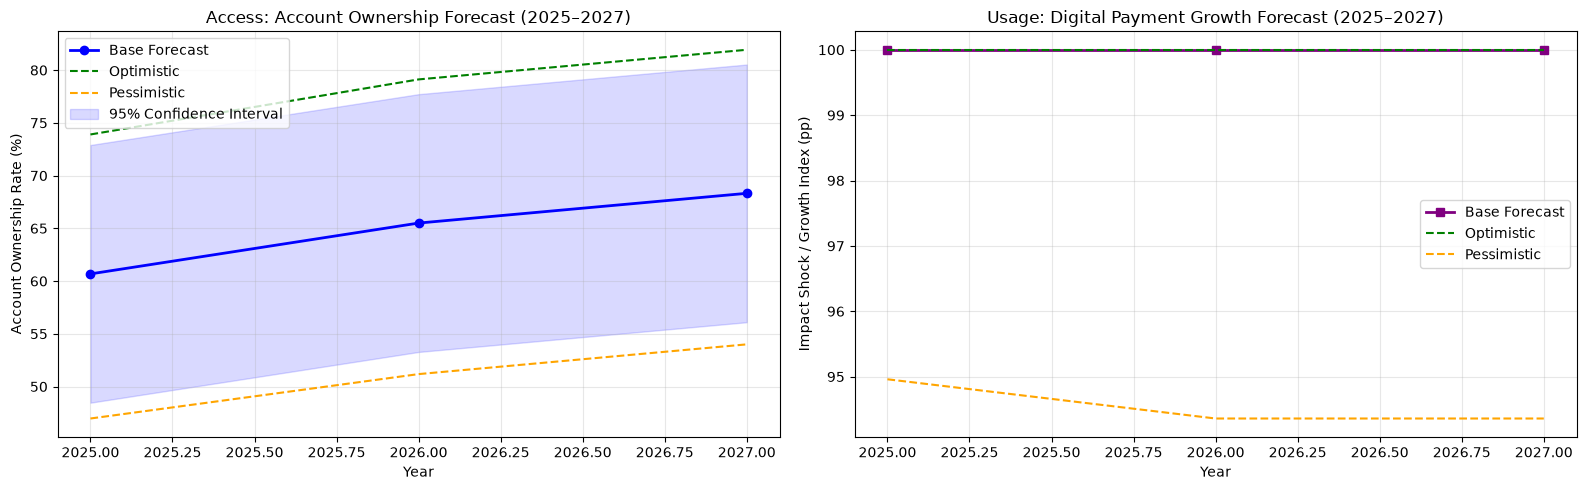

✅ Forecast visualization saved to reports/figures/task4_forecast_scenarios.png


In [6]:
FIG_DIR = '../reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Access Scenarios
axes[0].plot(df_access_fc['year'], df_access_fc['base_forecast'], marker='o', label='Base Forecast', color='blue', linewidth=2)
axes[0].plot(df_access_fc['year'], df_access_fc['optimistic_scenario'], linestyle='--', label='Optimistic', color='green')
axes[0].plot(df_access_fc['year'], df_access_fc['pessimistic_scenario'], linestyle='--', label='Pessimistic', color='orange')
axes[0].fill_between(df_access_fc['year'], df_access_fc['ci_lower_95'], df_access_fc['ci_upper_95'], color='blue', alpha=0.15, label='95% Confidence Interval')
axes[0].set_title("Access: Account Ownership Forecast (2025–2027)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Account Ownership Rate (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Usage Scenarios
axes[1].plot(df_usage_fc['year'], df_usage_fc['base_forecast'], marker='s', label='Base Forecast', color='purple', linewidth=2)
axes[1].plot(df_usage_fc['year'], df_usage_fc['optimistic_scenario'], linestyle='--', label='Optimistic', color='green')
axes[1].plot(df_usage_fc['year'], df_usage_fc['pessimistic_scenario'], linestyle='--', label='Pessimistic', color='orange')
axes[1].set_title("Usage: Digital Payment Growth Forecast (2025–2027)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Impact Shock / Growth Index (pp)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'task4_forecast_scenarios.png'))
plt.show()
print("✅ Forecast visualization saved to reports/figures/task4_forecast_scenarios.png")